# Conditional Autoencoder for ETF Rotation

**Purpose.** Evaluate whether a conditional autoencoder (CAE) can use ETF characteristics to
produce factor exposures that rank 21-day returns out of sample.

**Learning objectives**

- trace train-only CAE factor states through eight purged walk-forward folds;
- apply a reporting checkpoint fixed before validation results are inspected;
- compute one cross-sectional rank IC per decision date before averaging; and
- distinguish a positive point estimate from statistically reliable evidence.

**Book reference.** Chapter 14, Section 14.6, "Nonlinear conditional factor models."

**Prerequisites.** The ETF financial and model-based features, 21-day labels, and fold-scoped
temporal features produced by the case-study pipeline.

In [1]:
"""Evaluate the ETF conditional autoencoder through the shared model runner."""

import warnings

# Load PyTorch's bundled CUDA runtime before other ML4T libraries.
import torch  # noqa: F401

# isort: split
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython import get_ipython
from IPython.display import Markdown, display
from ml4t.diagnostic.metrics import compute_ic_uncertainty, cross_sectional_ic_series

from case_studies.utils.latent_factors.case_study import (
    configured_models,
    load_case_study_context,
    run_case_study_model,
)
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, add_message_title, zero_line

warnings.filterwarnings("ignore")
shell = get_ipython()
if shell is not None:
    shell.run_line_magic("matplotlib", "inline")

In [2]:
CASE_STUDY_ID = "etfs"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
N_FACTORS = 5
N_EPOCHS = 50
USE_CACHE = True
FORCE_RETRAIN = False
MAX_FOLDS = 0
MAX_VARIANT_LABELS = -1
USE_MACRO = False
MODEL_NAME = "cae"
SEED = 42

In [3]:
REPORTING_CHECKPOINT = 50
HORIZON = 21
set_global_seeds(SEED)

## Establish the evaluation contract

Each fold fits the beta and factor networks only on its training interval. The expanding mean of
training factor returns supplies the validation forecast premium, and 21 intervening trading dates
separate training from validation. All validation dates precede the sealed 2024-2025 holdout.

The input identity covers the complete financial, model-based, label, and setup artifacts. The ETF
universe was selected retrospectively, so this remains a development-validation estimate with
survivorship risk, not a live or unbiased holdout result. Three yield-curve features also use
finalized FRED history rather than a strict first-release vintage.

In [4]:
context = load_case_study_context(
    CASE_STUDY_ID,
    primary_label=PRIMARY_LABEL,
    max_symbols=MAX_SYMBOLS,
    max_folds=MAX_FOLDS,
    max_variant_labels=MAX_VARIANT_LABELS,
    use_macro=USE_MACRO,
)
assert MODEL_NAME in configured_models(context)
assert context.input_data_spec["version"] == "v1"

pl.DataFrame(
    {
        "label": [context.primary_label],
        "features": [len(context.feature_names)],
        "folds": [len(context.splits)],
        "input_version": [context.input_data_spec["version"]],
        "modeling_input_digest": [context.input_data_spec["input_digest"]],
    }
)

label,features,folds,input_version,modeling_input_digest
str,i64,i64,str,str
"""fwd_ret_21d""",71,8,"""v1""","""sha256:8384ded464c95f36b9baff0…"


## Run walk-forward validation

Epoch 50 is the predeclared reporting endpoint. The shared runner loads the newest exact
specification match when one exists; on a clean registry it trains and registers the same model
specification. Validation performance does not choose the reported checkpoint.

In [5]:
result = run_case_study_model(
    context,
    model_name=MODEL_NAME,
    notebook="11c_conditional_autoencoder",
    n_factors=N_FACTORS,
    n_epochs=N_EPOCHS,
    use_cache=USE_CACHE,
    force_retrain=FORCE_RETRAIN,
    reporting_epoch=REPORTING_CHECKPOINT,
)

model_result = result["model_results"][0]
assert model_result["best_epoch"] == REPORTING_CHECKPOINT
assert result["fold_metrics"][MODEL_NAME]["fold_id"].n_unique() == len(context.splits)
pl.DataFrame(result["model_results"])

Latent factor CV: 1 models × 8 folds
Log file: <ML4T_OUTPUT_DIR>/etfs/run_log/latent_factors.log
Scoring: dates=all cadence=- step=1 checkpoint_selection=fixed reporting_epoch=50
  cae: loaded registry (best IC=+0.0217)
  Best: cae (IC=+0.0217)


model_name,mean_ic,best_epoch,n_folds,elapsed_s,started_at
str,f64,i64,i64,f64,null
"""cae""",0.0217,50,8,0.0,null


## Contrast the fixed endpoint with validation diagnostics

The training schedule emits checkpoints every five epochs. Their validation ICs are useful
diagnostics, but the largest one cannot replace the endpoint fixed before evaluation.

In [6]:
checkpoint_summary = (
    result["fold_metrics"][MODEL_NAME]
    .group_by("epoch")
    .agg(pl.col("ic_mean").mean().alias("fold_mean_ic"))
    .sort("epoch")
)
validation_max = checkpoint_summary.sort("fold_mean_ic", descending=True).row(0, named=True)
fixed_summary = checkpoint_summary.filter(pl.col("epoch") == REPORTING_CHECKPOINT).row(
    0, named=True
)
validation_max_epoch = int(validation_max["epoch"])

pl.DataFrame(
    [
        {"role": "fixed report", **fixed_summary},
        {"role": "validation diagnostic maximum", **validation_max},
    ]
).select("role", "epoch", "fold_mean_ic")

role,epoch,fold_mean_ic
str,i64,f64
"""fixed report""",50,0.021699
"""validation diagnostic maximum""",40,0.044352


## Recompute daily IC and serial-correlation-aware uncertainty

The unit of evaluation is one decision date. Predictions and realized returns are ranked within
each date, producing one Spearman IC. The chronological mean gives every date equal weight, and a
20-lag Newey-West correction reflects overlap in the 21-day return label.

In [7]:
predictions = result["all_predictions"][MODEL_NAME].filter(pl.col("epoch") == REPORTING_CHECKPOINT)
assert predictions["fold_id"].n_unique() == len(context.splits)
assert predictions["timestamp"].max().year < 2024

daily_ic = cross_sectional_ic_series(
    predictions,
    predictions,
    pred_col="y_score",
    ret_col="y_true",
    date_col="timestamp",
    entity_col="symbol",
    method="spearman",
    min_obs=5,
).sort("timestamp")
daily_stats = compute_ic_uncertainty(daily_ic.select("ic"), horizon=HORIZON)

assert daily_stats["hac_lag"] == HORIZON - 1
assert np.isclose(daily_stats["mean_ic"], fixed_summary["fold_mean_ic"], atol=5e-5)

In [8]:
pl.DataFrame(
    {
        "mean_daily_ic": [daily_stats["mean_ic"]],
        "hac_t": [daily_stats["t_hac"]],
        "hac_p": [daily_stats["p_hac"]],
        "hac_ci_low": [daily_stats["ci_hac_lower"]],
        "hac_ci_high": [daily_stats["ci_hac_upper"]],
        "positive_days": [daily_stats["pct_positive"]],
        "n_dates": [daily_stats["n_days"]],
    }
).with_columns(pl.exclude("n_dates").round(4))

mean_daily_ic,hac_t,hac_p,hac_ci_low,hac_ci_high,positive_days,n_dates
f64,f64,f64,f64,f64,f64,i64
0.0217,0.9824,0.326,-0.0216,0.065,0.5407,2016


## Stability across validation years

A distinct timestamp-to-fold map attaches each daily IC to exactly one fold. This preserves every
date even when two dates happen to have the same IC value. The bars reveal whether the overall
mean is stable across validation regimes.

In [9]:
fold_dates = predictions.select("fold_id", "timestamp").unique()
assert fold_dates.height == daily_ic.height
fold_ic = (
    fold_dates.join(daily_ic, on="timestamp", how="inner")
    .group_by("fold_id")
    .agg(
        pl.col("timestamp").min().dt.year().alias("start_year"),
        pl.col("ic").mean().alias("mean_daily_ic"),
        pl.len().alias("n_dates"),
    )
    .sort("start_year")
)
assert fold_ic["n_dates"].sum() == daily_ic.height
positive_folds = fold_ic.filter(pl.col("mean_daily_ic") >= 0).height
negative_folds = fold_ic.filter(pl.col("mean_daily_ic") < 0).height
bar_colors = [
    COLORS["positive"] if value >= 0 else COLORS["negative"] for value in fold_ic["mean_daily_ic"]
]
interval_message = (
    "crosses zero"
    if daily_stats["ci_hac_lower"] <= 0 <= daily_stats["ci_hac_upper"]
    else "excludes zero"
)

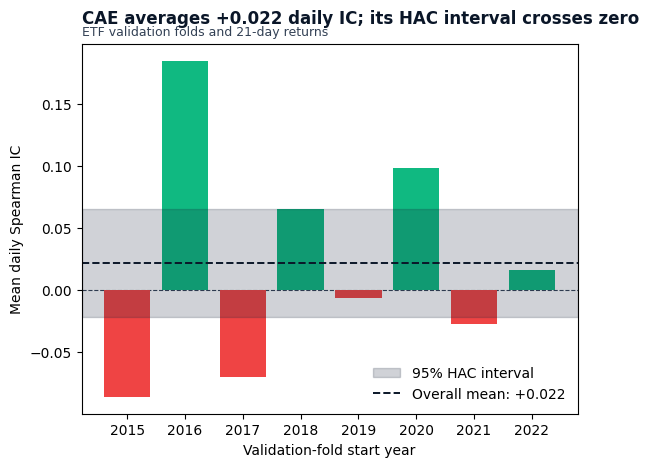

In [10]:
fig, ax = plt.subplots()
ax.bar(
    fold_ic["start_year"].cast(pl.String).to_list(),
    fold_ic["mean_daily_ic"].to_list(),
    color=bar_colors,
)
ax.axhspan(
    daily_stats["ci_hac_lower"],
    daily_stats["ci_hac_upper"],
    color=COLORS["blue_light"],
    alpha=0.2,
    label="95% HAC interval",
)
zero_line(ax)
ax.axhline(
    daily_stats["mean_ic"],
    color=COLORS["blue"],
    linestyle="--",
    linewidth=1.4,
    label=f"Overall mean: {daily_stats['mean_ic']:+.3f}",
)
ax.set_xlabel("Validation-fold start year")
ax.set_ylabel("Mean daily Spearman IC")
ax.legend(frameon=False, loc="lower right")
add_message_title(
    ax,
    f"CAE averages {daily_stats['mean_ic']:+.3f} daily IC; its HAC interval {interval_message}",
    subtitle="ETF validation folds and 21-day returns",
)
display(
    fig,
    metadata={
        "image/png": {
            "alt": "Mean daily CAE rank IC by ETF validation fold, with the overall mean and "
            "95% HAC interval."
        }
    },
)
plt.close(fig)

In [11]:
inference = (
    "statistically inconclusive"
    if daily_stats["ci_hac_lower"] <= 0 <= daily_stats["ci_hac_upper"]
    else "statistically distinguishable from zero"
)
display(
    Markdown(
        f"""
## Takeaways

- The fixed epoch-{REPORTING_CHECKPOINT} checkpoint averages
  **{daily_stats["mean_ic"]:+.4f} daily IC** across {daily_stats["n_days"]:,} validation dates,
  with a 95% HAC interval of
  **[{daily_stats["ci_hac_lower"]:+.4f}, {daily_stats["ci_hac_upper"]:+.4f}]**
  (*t* = {daily_stats["t_hac"]:.2f}, *p* = {daily_stats["p_hac"]:.4f}). The estimate is
  {inference}.
- {positive_folds} folds have positive mean IC and {negative_folds} are negative, so performance is
  not stable across validation regimes.
- Checkpoint {validation_max_epoch} has the largest validation IC, but it remains a diagnostic and
  cannot replace the fixed reporting endpoint.
- The backward-selected ETF universe and finalized-FRED yield-curve features make this a
  retrospective development result, not a live or unbiased holdout estimate.

**Next:** `11d_stochastic_discount_factor` and `11e_supervised_autoencoder` complete the nonlinear
factor estimators; `13_model_analysis` compares all accepted model families.
"""
    )
)


## Takeaways

- The fixed epoch-50 checkpoint averages
  **+0.0217 daily IC** across 2,016 validation dates,
  with a 95% HAC interval of
  **[-0.0216, +0.0650]**
  (*t* = 0.98, *p* = 0.3260). The estimate is
  statistically inconclusive.
- 4 folds have positive mean IC and 4 are negative, so performance is
  not stable across validation regimes.
- Checkpoint 40 has the largest validation IC, but it remains a diagnostic and
  cannot replace the fixed reporting endpoint.
- The backward-selected ETF universe and finalized-FRED yield-curve features make this a
  retrospective development result, not a live or unbiased holdout estimate.

**Next:** `11d_stochastic_discount_factor` and `11e_supervised_autoencoder` complete the nonlinear
factor estimators; `13_model_analysis` compares all accepted model families.
